In [2]:
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids, FuzzyInputVariable_List_Trapezoids
from operators import productN
import numpy as np
#from helps_and_enhancers import *
import matplotlib.pyplot as plt
from ANFIS import ANFIS
import time
import copy
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
from scipy.optimize import minimize, basinhopping
from scipy.stats import variation
import scipy.optimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import permutations, combinations
import time
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from helps_and_enhancers import calculate_combinations, my_reshape
# from operators import productN
from params import FuzzyInputVariable_3Trapezoids, FuzzyInputVariable_2Trapezoids

from goal_function_object import *

def productN(args, op):
    return np.prod(args, axis=0)


class ANFIS:
    
    def __init__(self, inputs, training_data: np.ndarray, expected_labels: np.ndarray, operator_function=productN, operator_init_value=0.5):
        self.input_list = inputs
        self.input_number = len(inputs)
        self.training_data = training_data
        self.expected_labels = expected_labels
        
        self.premises = []
        for i in range(self.input_number):
            self.premises.append(self.input_list[i].get())

        self.nodes_number = np.prod([inp.n_functions for inp in self.input_list])
        
        self.operator_function=operator_function
        
        #self.tsk = np.ones((self.nodes_number ,self.input_number+1))
        self.tsk = np.random.random((self.nodes_number ,self.input_number+1))
        
        self.op  = [operator_init_value]*self.nodes_number

        self.calculate_aids()

    #Wyswietlanie funkcji przynależnosci
    def show_inputs(self):
        plt.figure()
        for i in range(self.input_number):
            plt.subplot(self.input_number, 1, i+1)
            self.input_list[i].show()
            plt.legend()
        plt.show()

    def set_premises_parameters(self, fv):
        fv = np.array(fv).reshape(np.shape(self.premises))
        self.premises=fv
        for i in range(self.input_number):
            self.input_list[i].set(*fv[i])
             
    def calculate_aids(self):
        self.premises_combinations = np.array(calculate_combinations(self))[:,::-1]

    def output_to_labels(self, y_pred):
        rounded = np.round(y_pred.flatten()).astype(int)
        r_shape = np.shape(rounded)
        return np.max((np.min((rounded , np.ones(r_shape)),axis=0), np.zeros(r_shape)),axis=0)#clamp 0-1       
               
    def anfis_estimate_labels(self, fv, op, tsk) -> np.ndarray:

        data = self.training_data

        self.set_premises_parameters(fv)
        tsk=np.reshape(tsk,np.shape(self.tsk))
        memberships = [self.input_list[x].fuzzify(data[x]) for x in range(self.input_number)]
        
        #Wnioskowanie
        arguments = []
        for premises in self.premises_combinations:
            item = []
            for i in range(len(premises)):
                item.append(np.array(memberships[i])[:,premises[i]])
            arguments.append(   item  )

        arguments = np.transpose(arguments, (1,2,0))
        
        R=self.operator_function(arguments, op)
        
        #Normalizacja normalizacja poziomów aktywacji reguł
        Rsum = np.sum(R, axis=1, keepdims=True)

        Rnorm = R / Rsum
        Rnorm[(Rsum==0).flatten(),:] = 0
        # wylicz wartoci przesłanek dla każdej próbki
        
        dataXYZ1 = np.vstack((self.training_data,np.ones(len(self.training_data[0])))).T
        Q = np.dot(dataXYZ1, tsk.T) 
        
        # wyznacz wyniki wnioskowania dla każdej próbki
        result = (Q * Rnorm).sum(axis=1, keepdims=True)
    
        return result.T    
        
    def show_results(self, color=None):
        
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        
        if color is None:
            color = [[1,0,0] if cc else [0,1,0] for cc in self.expected_labels]

        result = self.anfis_estimate_labels(self.premises,self.op,self.tsk)
        # print(result)
        #ax.scatter(np.array(self.training_data)[:,0], np.array(self.training_data)[:,1], result, c=rgb)
        ax.scatter(self.training_data[0], self.training_data[1], result, c=color)
        
        plt.show()
    
    def set_training_and_testing_data(self, training_data, expected_labels):
        self.training_data = training_data
        self.expected_labels = expected_labels
        
    def train(self, global_optimization: bool, learn_premises: bool, learn_operators: bool, learn_consequents: bool, n_iter=100, bounds_premises=None):
        
        x1 = [ item for sublist in self.premises for item in sublist ]
        x1 = np.array(x1).flatten()
        x2 = self.op
        x3 = self.tsk.flatten()
          
        if bounds_premises is None:
            bfv = [(0,4)]*len(x1)
        else:
            bfv = bounds_premises
        bop  = [(0.0,2.0)]*len(x2)
        btsk = [(0,2)]*len(x3)
        
        niter_success=100
            
        if learn_premises and learn_operators and learn_consequents:
            x0 = np.hstack((x1,x2,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
            
        elif learn_premises and learn_operators:
            x0 = np.hstack((x1,x2))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)+len(x2)
            
            bounds = bfv + bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:self.end_x1].reshape(np.shape(self.premises)))
            self.op=res.x[self.end_x1:self.end_x2]

        elif learn_premises and learn_consequents:
            x0 = np.hstack((x1,x3))
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self)}
                res = basinhopping(goal_premises_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter)#, niter_success=niter_success)
            else:
                res = minimize(goal_premises_consequents, x0, method='SLSQP', bounds=bounds, args=self, tol=1e-6)

            self.set_premises_parameters(res.x[:self.end_x1]) ##zmiana funkcji
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))

        elif learn_operators and learn_consequents:
            print("4")
            x0 = np.hstack((x2,x3))
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop + btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[self.end_x1:self.end_x2]
            self.tsk=res.x[self.end_x2:].reshape(np.shape(self.tsk))
        
        elif learn_premises:
            x0 = x1
            self.end_x1 = len(x1)
            self.end_x2 = len(x1)
            
            bounds = bfv

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_premises, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_premises, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.set_premises_parameters(res.x[:].reshape(np.shape(self.premises)))

        elif learn_operators:
            x0 = x2
            self.end_x1 = 0
            self.end_x2 = len(x2)
            
            bounds = bop

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds}
                res = basinhopping(goal_operators, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_operators, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.op=res.x[:]
            
        elif learn_consequents:
            x0 = x3
            self.end_x1 = 0
            self.end_x2 = 0
            
            bounds = btsk

            if global_optimization:
                minimizer_kwargs = {"method":"SLSQP", "bounds": bounds, "args":(self), "tol":1e-03}
                res = basinhopping(goal_consequents, x0, minimizer_kwargs=minimizer_kwargs, niter=n_iter, niter_success=niter_success) 
            else:
                res = minimize(goal_consequents, x0, method='SLSQP', bounds=bounds, args=self)
                
            self.tsk=res.x[:].reshape(np.shape(self.tsk))
            
        else:
            print("Error")
            assert(0)
            
        print("Optymalizacja zakończona!")
        print("z blędem:  ", res.fun)
        print("Liczba ew: ", res.nfev)
        print("Liczba it: ", res.nit)


<H1>Przygotowanie zbioru danych: XOR<H1>

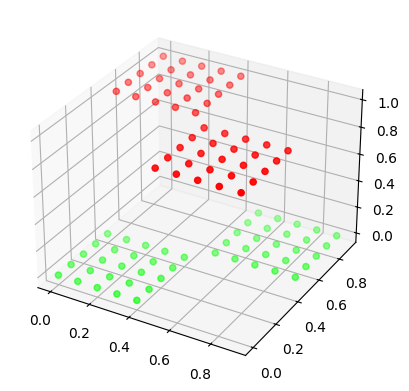

In [4]:
x = np.arange(0, 1, 0.1)
x,y = np.meshgrid(x, x)

dataX = x.flatten()
dataY = y.flatten()
dataXY1 = np.column_stack((dataX,dataY,np.ones(len(dataX))))
dataXY = np.column_stack((dataX,dataY))

data_labels = np.logical_xor(dataX >= 0.5, dataY >= 0.5) 

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

rgb = [[1,0,0] if cc else [0,1,0] for cc in data_labels]

ax.scatter(dataX, dataY, data_labels, c=rgb)

plt.show()

<H1>Utworzenie funkcji przynależności</H1>

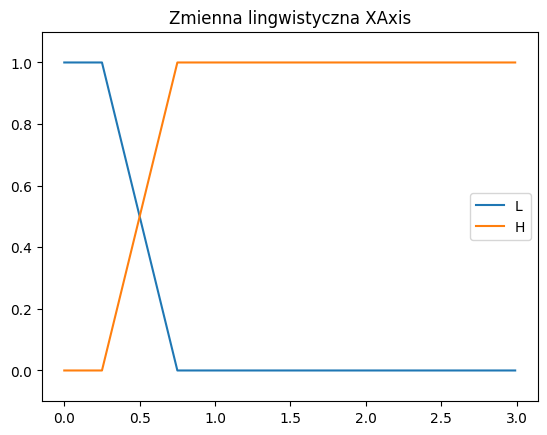

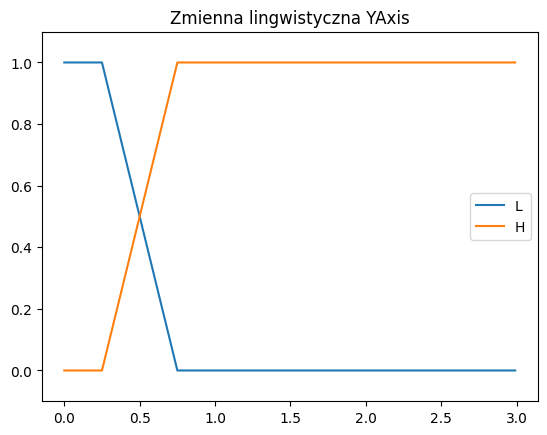

In [5]:
varX = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "XAxis", ["L","H"]) # low, high
varY = FuzzyInputVariable_2Trapezoids(0.5, 0.5, "YAxis", ["L","H"])

#mf1 = [[-0.5, 0.25, 0.25, 0.25], [0.5, 0.25, 0.1, 0.1]]
#varX = FuzzyInputVariable_List_Trapezoids(mf1, "XAxis", ["L","H"])
#varY = FuzzyInputVariable_List_Trapezoids(mf1, "YAxis", ["L","H"])

#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

<H1>Inicjalizacja systemu ANFIS</H1>

Parametry początkowe:
Przesłanki:  [[0.5, 0.5], [0.5, 0.5]] 
Konkluzje:  [[0.22157836 0.99151487 0.60561574]
 [0.86410485 0.75614174 0.33812561]
 [0.78672512 0.74493828 0.5194792 ]
 [0.1963119  0.33307566 0.97642182]]
[[1.11542982 0.91805714 1.08070698 0.76141378 1.04707593 0.82607655
  1.18132344 1.38136699 0.87528381 1.35159595 0.7490829  1.02043716
  1.47437155 1.41685542 0.92477117 1.42491534 1.45964399 1.35374476
  1.02501601 0.78319352 1.00273907 1.37825007 1.19143415 0.80391871
  0.98653153 1.2631377  1.14197971 0.72692506 1.34648022 1.38583274
  1.06681001 0.74329148 0.64993141 1.09749111 1.25396622 1.38473103
  1.05575876 0.94679153 1.16498273 0.88705925 0.97931832 1.13983106
  1.44631054 1.10502367 1.37869351 1.41214186 1.36941031 1.03666692
  0.70476723 0.94267786 1.11581998 1.08232529 1.34726868 0.90385616
  1.28271454 1.24340382 1.31231681 1.39993186 0.84823438 1.42870811
  1.27277485 1.12776972 1.39750604 1.22170944 0.66461603 1.33369877
  0.62777357 1.41791505 0.91486855

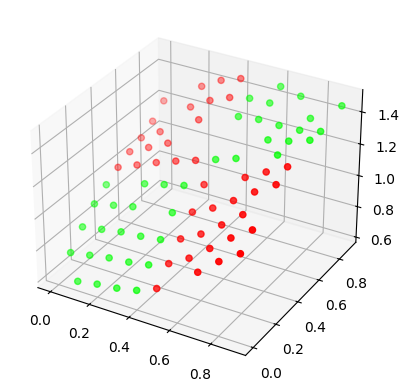

In [6]:
X_train, X_test, y_train, y_test = train_test_split(dataXY, data_labels, test_size=0.2, random_state=25)

fis = ANFIS([varX, varY], X_train.T, y_train)

print("Parametry początkowe:\nPrzesłanki: ",fis.premises, "\nKonkluzje: ", fis.tsk)

fis.show_results()

<H1>Uczenie systemu ANFIS</H1>

Optymalizacja zakończona!
z blędem:   3.315483163183541e-06
Liczba ew:  34266
Liczba it:  50
TIME elapsed:  4.403958320617676
[[9.99999991e-01 1.00000014e+00 1.00000014e+00 6.46975567e-12
  9.99999990e-01 6.28285785e-12 9.99999990e-01 9.34701585e-12
  7.24110299e-12 9.08801981e-12 6.15034062e-12 1.00000014e+00
  9.35764046e-12 9.99999991e-01 1.00000014e+00 8.59127693e-12
  9.99999991e-01 9.33639125e-12 7.50613745e-12 6.78917072e-12
  1.00000014e+00 9.59538729e-12 1.00000014e+00 5.96344280e-12
  1.00000014e+00 8.32165627e-12 9.99999990e-01 5.83092558e-12
  9.99999991e-01 9.85438334e-12 9.99999991e-01 1.00000014e+00
  5.69840835e-12 9.99999990e-01 1.00000014e+00 8.83964837e-12
  7.82555250e-12 6.86730736e-12 1.00000014e+00 6.41537508e-12
  7.69303527e-12 9.99999991e-01 9.86500794e-12 1.00000014e+00
  1.00000014e+00 1.03617508e-11 8.33228088e-12 9.99999991e-01
  5.51151053e-12 7.05420517e-12 1.00000014e+00 1.00000014e+00
  9.99999991e-01 1.00000014e+00 9.99999991e-01 1.00000014e+00
  1.00

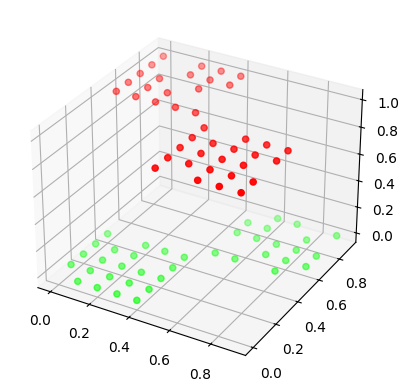

In [7]:
start = time.time()
fis.train(True, True, False, True, n_iter=50)
end = time.time()
print("TIME elapsed: ", end - start)   
fis.training_data = X_train.T
fis.expected_labels = y_train
fis.show_results()

[[7.18672240e-12 1.00000014e+00 7.37362022e-12 8.07328483e-12
  9.99999991e-01 1.00000014e+00 8.82902376e-12 1.06207469e-11
  9.60601190e-12 1.03723754e-11 5.05957825e-12 9.99999991e-01
  9.99999991e-01 9.99999991e-01 8.58065232e-12 9.99999991e-01
  8.85027297e-12 9.99999991e-01 9.84375873e-12 1.00000014e+00]]


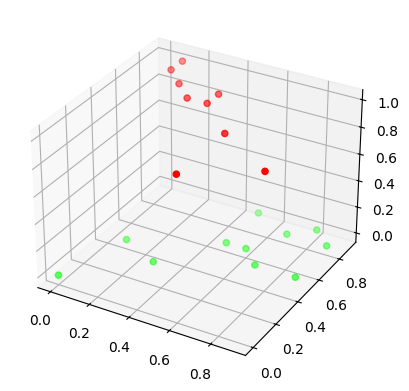

[[11  0]
 [ 0  9]]


In [8]:
fis.training_data = X_test.T
fis.expected_labels = y_test
fis.show_results()

y_pred = fis.anfis_estimate_labels(fis.premises,fis.op,fis.tsk)
y_pred = list(map(round,y_pred.flatten()))
print(confusion_matrix(y_test, y_pred))

<H1>Sprawdzanie parametrów jakich nauczył się system</H1>

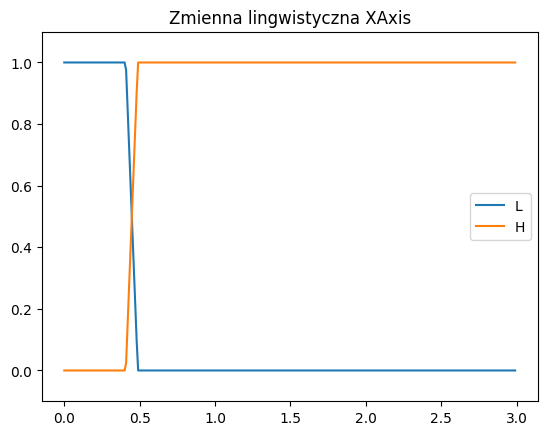

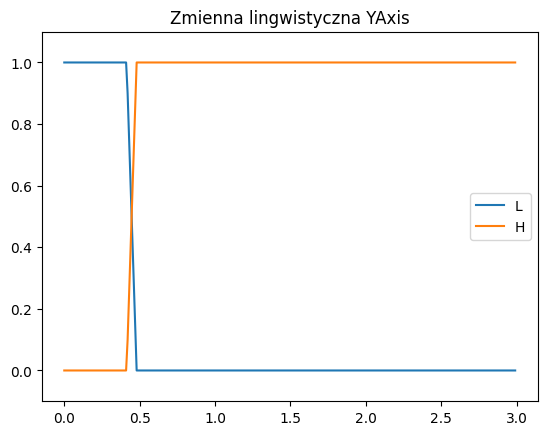

In [9]:
#Wyświetlanie funkcji przynależnosci
plt.figure()
varX.show()
plt.legend()

plt.figure()
varY.show()
plt.legend()

plt.show()

In [10]:
print("Parametry końcowe:\nPrzesłanki: ", repr(fis.premises), "\nKonkluzje: ", repr(fis.tsk))

Parametry końcowe:
Przesłanki:  array([[0.44793978, 0.07964361],
       [0.44655997, 0.06628897]]) 
Konkluzje:  array([[3.19415047e-12, 4.51932276e-12, 5.05957825e-12],
       [2.50173077e-16, 2.01816582e-13, 1.00000014e+00],
       [1.46351627e-13, 1.73615119e-09, 9.99999990e-01],
       [5.07367486e-12, 2.58996046e-12, 3.98247112e-12]])


<H1>Sprawdzanie wpływu parametrów na wyniki systemu</H1>

[[5.05957825e-12 5.37899330e-12 5.69840835e-12 6.01782339e-12
  6.33723844e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 5.51151053e-12 5.83092558e-12
  6.15034062e-12 6.46975567e-12 6.78917072e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  5.96344280e-12 6.28285785e-12 6.60227290e-12 6.92168794e-12
  7.24110299e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 6.41537508e-12 6.73479013e-12
  7.05420517e-12 7.37362022e-12 7.69303527e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  6.86730736e-12 7.18672240e-12 7.50613745e-12 7.82555250e-12
  8.14496754e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 9.99999990e-01 9.99999990e-01
  9.99999990e-01 9.99999990e-01 9.99999990e-01 7.81428879e-12
  8.32165627e-12 8.82902376e-12 9.33639125e-12 9.84375873e-12
  9.99999991e-01 9.99999991e-01 9.99999991e-01 9.99999991e-01
  9.9999

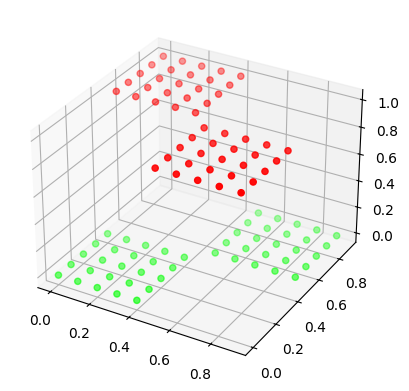

In [11]:
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

[[5.05957825e-12 5.37899330e-12 5.69840835e-12 6.01782339e-12
  6.33723844e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 5.51151053e-12 5.83092558e-12
  6.15034062e-12 6.46975567e-12 6.78917072e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  5.96344280e-12 6.28285785e-12 6.60227290e-12 6.92168794e-12
  7.24110299e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 6.41537508e-12 6.73479013e-12
  7.05420517e-12 7.37362022e-12 7.69303527e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  6.86730736e-12 7.18672240e-12 7.50613745e-12 7.82555250e-12
  8.14496754e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 9.99999990e-01 9.99999990e-01
  9.99999990e-01 9.99999990e-01 9.99999990e-01 7.81428879e-12
  8.32165627e-12 8.82902376e-12 9.33639125e-12 9.84375873e-12
  9.99999991e-01 9.99999991e-01 9.99999991e-01 9.99999991e-01
  9.9999

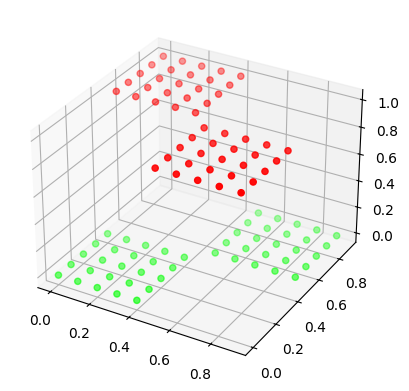

In [12]:
# fis.premises = ##################
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

[[5.05957825e-12 5.37899330e-12 5.69840835e-12 6.01782339e-12
  6.33723844e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 5.51151053e-12 5.83092558e-12
  6.15034062e-12 6.46975567e-12 6.78917072e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  5.96344280e-12 6.28285785e-12 6.60227290e-12 6.92168794e-12
  7.24110299e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 6.41537508e-12 6.73479013e-12
  7.05420517e-12 7.37362022e-12 7.69303527e-12 1.00000014e+00
  1.00000014e+00 1.00000014e+00 1.00000014e+00 1.00000014e+00
  6.86730736e-12 7.18672240e-12 7.50613745e-12 7.82555250e-12
  8.14496754e-12 1.00000014e+00 1.00000014e+00 1.00000014e+00
  1.00000014e+00 1.00000014e+00 9.99999990e-01 9.99999990e-01
  9.99999990e-01 9.99999990e-01 9.99999990e-01 7.81428879e-12
  8.32165627e-12 8.82902376e-12 9.33639125e-12 9.84375873e-12
  9.99999991e-01 9.99999991e-01 9.99999991e-01 9.99999991e-01
  9.9999

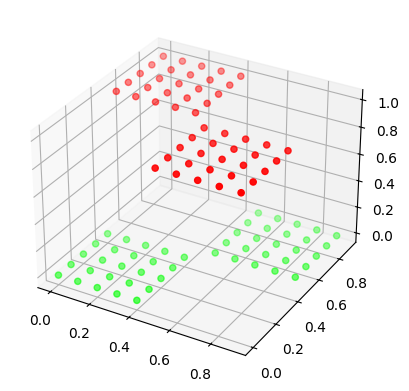

In [13]:
# fis.tsk = ##################
fis.training_data = dataXY.T
fis.expected_labels = data_labels
fis.show_results()

<H1>Zadanie</H1>

Naucz system ANFIS tabliczki mnożenia. Zacznij od rozmiaru 2x2 i zwiększaj w obu kierunkach z krokiem 1 (kolejno 2x2, 3x3, 4x4, 5x5). Mierz czas jaki jest potrzebny na nauczenie systemu w zależności od wymiarów tabliczki. Zrób wykres wymiaru tabliczki od czasu uczenia.

[0. 0.] = 0
[0.25 0.  ] = 0
[0.5 0. ] = 0
[0.75 0.  ] = 0
[1. 0.] = 0
[1.25 0.  ] = 0
[1.5 0. ] = 0
[1.75 0.  ] = 0
[2. 0.] = 0
[0.   0.25] = 0
[0.25 0.25] = 0
[0.5  0.25] = 0
[0.75 0.25] = 0
[1.   0.25] = 0
[1.25 0.25] = 0
[1.5  0.25] = 0
[1.75 0.25] = 0
[2.   0.25] = 0
[0.  0.5] = 0
[0.25 0.5 ] = 0
[0.5 0.5] = 0
[0.75 0.5 ] = 0
[1.  0.5] = 0
[1.25 0.5 ] = 1
[1.5 0.5] = 1
[1.75 0.5 ] = 1
[2.  0.5] = 1
[0.   0.75] = 0
[0.25 0.75] = 0
[0.5  0.75] = 0
[0.75 0.75] = 1
[1.   0.75] = 1
[1.25 0.75] = 1
[1.5  0.75] = 1
[1.75 0.75] = 1
[2.   0.75] = 2
[0. 1.] = 0
[0.25 1.  ] = 0
[0.5 1. ] = 0
[0.75 1.  ] = 1
[1. 1.] = 1
[1.25 1.  ] = 1
[1.5 1. ] = 2
[1.75 1.  ] = 2
[2. 1.] = 2
[0.   1.25] = 0
[0.25 1.25] = 0
[0.5  1.25] = 1
[0.75 1.25] = 1
[1.   1.25] = 1
[1.25 1.25] = 2
[1.5  1.25] = 2
[1.75 1.25] = 2
[2.   1.25] = 2
[0.  1.5] = 0
[0.25 1.5 ] = 0
[0.5 1.5] = 1
[0.75 1.5 ] = 1
[1.  1.5] = 2
[1.25 1.5 ] = 2
[1.5 1.5] = 2
[1.75 1.5 ] = 3
[2.  1.5] = 3
[0.   1.75] = 0
[0.25 1.75] = 0
[0.5  1.75] 

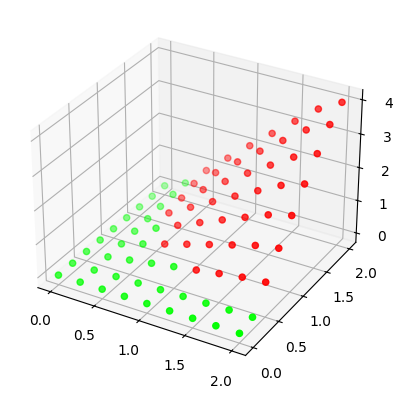

In [ ]:
n = 2

x = np.arange(0, n+0.25, 0.25)
y = np.arange(0, n+0.25, 0.25)
xx, yy = np.meshgrid(x, y)

dataX = xx.flatten()
dataY = yy.flatten()
dataXY = np.column_stack((dataX, dataY))
data_labels = np.round(dataX * dataY).astype(int)

varX = FuzzyInputVariable_2Trapezoids(n/2, n/2, "X", ["L", "H"])
varY = FuzzyInputVariable_2Trapezoids(n/2, n/2, "Y", ["L", "H"])

# for i, res in zip(dataXY, data_labels):
#     print(f"{i} = {res}")


fis = ANFIS([varX, varY], dataXY.T, data_labels)

start = time.time()
fis.train(global_optimization=True, learn_premises=True, learn_operators=False, learn_consequents=True, n_iter=100)
end = time.time()
elapsed = end - start
# times.append(elapsed)

print(f"Rozmiar tabliczki: {n}x{n}, czas uczenia: {elapsed:.2f} s")
fis.show_results()

Optymalizacja zakończona!
z blędem:   19.0
Liczba ew:  1632
Liczba it:  50
Rozmiar tabliczki: 1x1, czas uczenia: 0.23 s
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0.]]


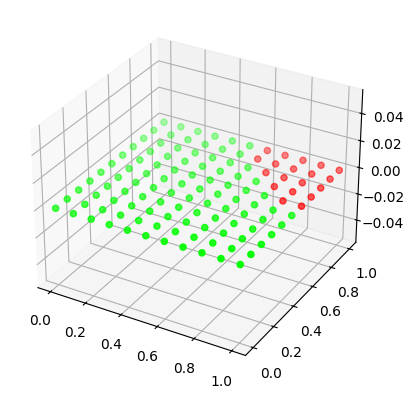

Optymalizacja zakończona!
z blędem:   92.06280560443228
Liczba ew:  62148
Liczba it:  50
Rozmiar tabliczki: 2x2, czas uczenia: 9.49 s
[[4.22235768e-11 4.38583893e-11 4.54932017e-11 4.54544401e-11
  4.54034762e-11 4.53403240e-11 4.52649835e-11 4.51774547e-11
  4.50777376e-11 4.49658322e-11 4.48417385e-11 4.47054565e-11
  4.45569862e-11 4.43963276e-11 4.42234807e-11 4.40384455e-11
  4.38412220e-11 4.36318102e-11 4.34102101e-11 4.31764217e-11
  4.30899733e-11 4.38655555e-11 4.55003680e-11 4.71351805e-11
  4.28597509e-03 8.57198587e-03 1.28579966e-02 1.71440074e-02
  2.14300182e-02 2.57160290e-02 3.00020398e-02 3.42880505e-02
  3.85740613e-02 4.28600721e-02 4.71460829e-02 5.14320937e-02
  5.57181044e-02 6.00041152e-02 6.42901260e-02 6.85761368e-02
  7.28621476e-02 7.67634272e-02 4.55075342e-11 4.71423467e-11
  4.87771592e-11 8.57195013e-03 1.71439717e-02 2.57159932e-02
  3.42880148e-02 4.28600364e-02 5.14320579e-02 6.00040795e-02
  6.85761010e-02 7.71481226e-02 8.57201442e-02 9.42921657e-0

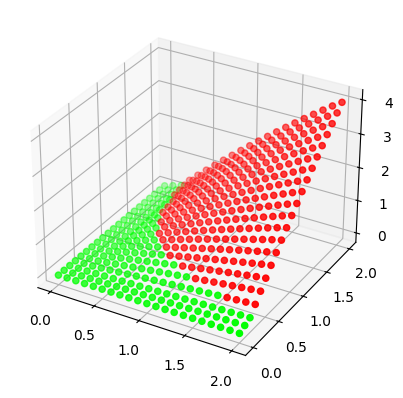

Optymalizacja zakończona!
z blędem:   221.94098453602822
Liczba ew:  53178
Liczba it:  50
Rozmiar tabliczki: 3x3, czas uczenia: 9.38 s
[[1.69656125e-12 1.78372727e-12 1.82192545e-12 1.85930487e-12
  1.89586551e-12 1.93160740e-12 1.96653051e-12 2.00063486e-12
  2.03392044e-12 2.06638725e-12 2.09803529e-12 2.12886457e-12
  2.15887508e-12 2.18806682e-12 2.21643979e-12 2.24399400e-12
  2.27072943e-12 2.29664611e-12 2.32174401e-12 2.34602315e-12
  2.36948351e-12 2.39212511e-12 2.41394795e-12 2.43495201e-12
  2.45513731e-12 2.47450384e-12 2.49305161e-12 2.51078060e-12
  2.52769083e-12 2.54378229e-12 2.55905498e-12 1.74746350e-12
  6.41941518e-09 4.69334553e-03 9.38668458e-03 1.40800236e-02
  1.87733625e-02 2.34667014e-02 2.81600403e-02 3.28533791e-02
  3.75467178e-02 4.22400565e-02 4.69333951e-02 5.16267337e-02
  5.63200723e-02 6.10134107e-02 6.57067492e-02 7.04000875e-02
  7.50934259e-02 7.97867641e-02 8.44801023e-02 8.91734405e-02
  9.38667786e-02 9.85601167e-02 1.03253455e-01 1.07946793e-

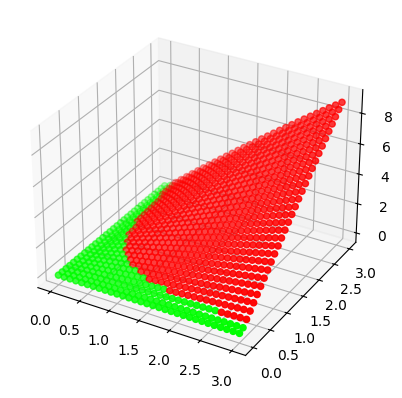

Optymalizacja zakończona!
z blędem:   400.58954759573425
Liczba ew:  41954
Liczba it:  50
Rozmiar tabliczki: 4x4, czas uczenia: 8.79 s
[[1.27883181e-10 1.32476429e-10 1.34746609e-10 ... 1.51450607e+01
  1.55352841e+01 1.59248609e+01]]


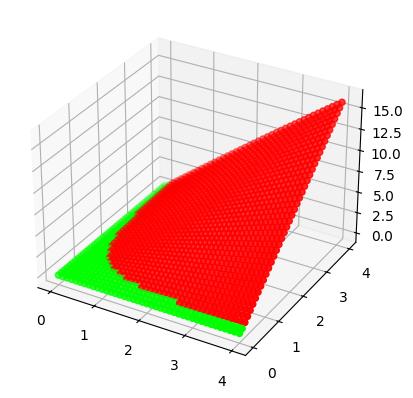

Optymalizacja zakończona!
z blędem:   859.2968842299031
Liczba ew:  28722
Liczba it:  50
Rozmiar tabliczki: 5x5, czas uczenia: 7.12 s
[[2.01652883e-11 8.96537944e-03 1.79307589e-02 ... 2.16000000e+01
  2.18000000e+01 2.20000000e+01]]


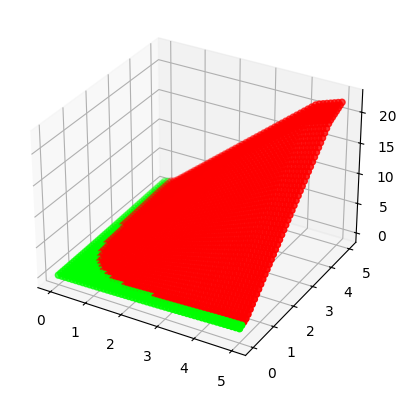

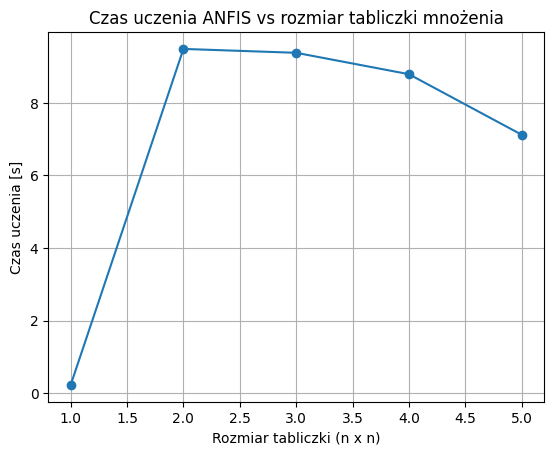

In [15]:
import time
import matplotlib.pyplot as plt

sizes = [1, 2, 3, 4, 5]
times = []

for n in sizes:
    x = np.arange(0, n+0.1, 0.1)
    y = np.arange(0, n+0.1, 0.1)
    xx, yy = np.meshgrid(x, y)

    dataX = xx.flatten()
    dataY = yy.flatten()
    dataXY = np.column_stack((dataX, dataY))
    data_labels = np.round(dataX * dataY).astype(int)

    # print(dataX)
    # print(dataY)
    # print(data_labels)

    varX = FuzzyInputVariable_2Trapezoids(n, n, "X", ["L", "H"])
    varY = FuzzyInputVariable_2Trapezoids(n, n, "Y", ["L", "H"])

    fis = ANFIS([varX, varY], dataXY.T, data_labels)

    start = time.time()
    fis.train(global_optimization=True, learn_premises=True, learn_operators=False, learn_consequents=True, n_iter=50)
    end = time.time()
    elapsed = end - start
    times.append(elapsed)

    print(f"Rozmiar tabliczki: {n}x{n}, czas uczenia: {elapsed:.2f} s")
    fis.show_results()

plt.figure()
plt.plot(sizes, times, marker='o')
plt.xlabel('Rozmiar tabliczki (n x n)')
plt.ylabel('Czas uczenia [s]')
plt.title('Czas uczenia ANFIS vs rozmiar tabliczki mnożenia')
plt.grid(True)
plt.show()

